In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

In [6]:
train = pd.read_csv("train_data.csv")

In [3]:
X = train.iloc[:, :-1]
Y = train.iloc[:,-1]

In [4]:
X.shape

(54808, 13)

In [5]:
X.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [7]:
X.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
employee_id,54808.0,NaN,NaN,NaN,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
department,54808,9,Sales & Marketing,16840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,54808,34,region_2,12343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,52399,3,Bachelor's,36669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,54808,2,m,38496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recruitment_channel,54808,3,other,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_trainings,54808.0,NaN,NaN,NaN,1.253011,0.609264,1.0,1.0,1.0,1.0,10.0
age,54808.0,NaN,NaN,NaN,34.803915,7.660169,20.0,29.0,33.0,39.0,60.0
previous_year_rating,50684.0,NaN,NaN,NaN,3.329256,1.259993,1.0,3.0,3.0,4.0,5.0
length_of_service,54808.0,NaN,NaN,NaN,5.865512,4.265094,1.0,3.0,5.0,7.0,37.0


In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,54808.0,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.00,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.00,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.00,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.00,5.0,7.0,37.0
KPIs_met >80%,54808.0,0.351974,0.477590,0.0,0.00,0.0,1.0,1.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.00,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.00,60.0,76.0,99.0


In [9]:
X.isnull().sum().sort_values(ascending=False)

previous_year_rating    4124
education               2409
employee_id                0
region                     0
department                 0
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

In [10]:
Y.value_counts()

is_promoted
0    50140
1     4668
Name: count, dtype: int64

In [11]:
Y.shape

(54808,)

department 9


department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64

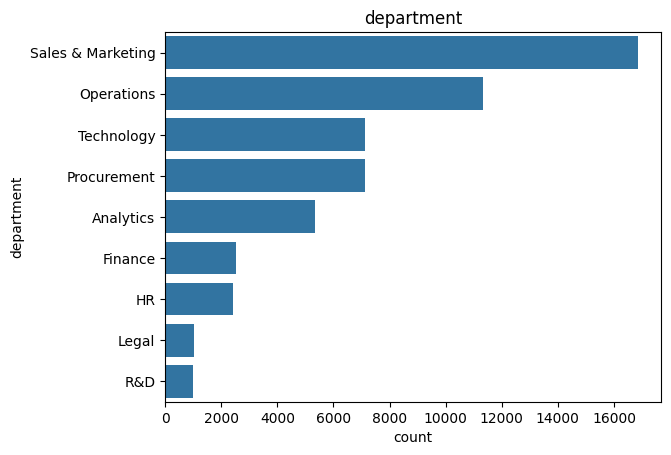

region 34


region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
Name: count, dtype: int64

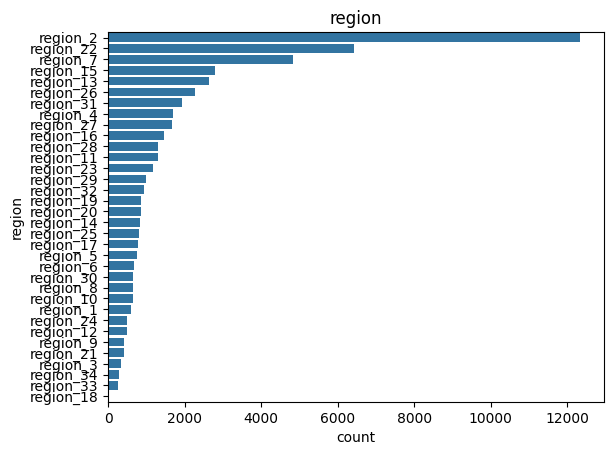

education 3


education
Bachelor's          36669
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64

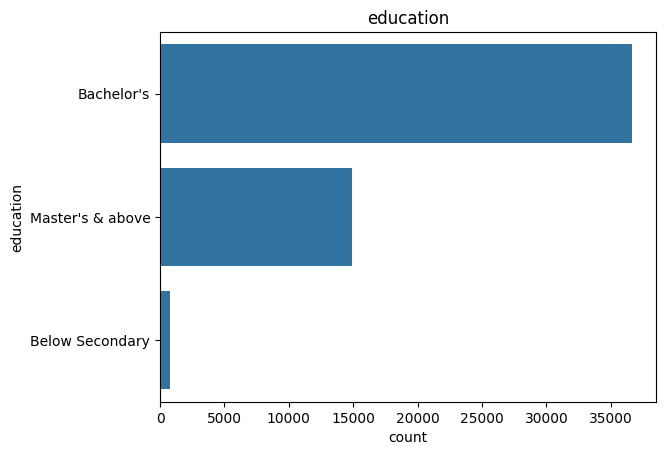

gender 2


gender
m    38496
f    16312
Name: count, dtype: int64

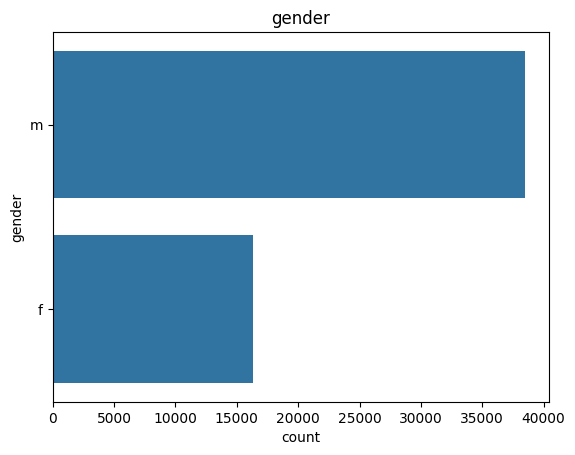

recruitment_channel 3


recruitment_channel
other       30446
sourcing    23220
referred     1142
Name: count, dtype: int64

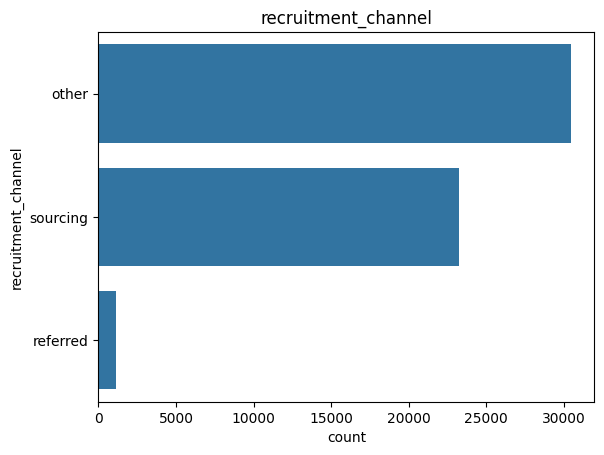

In [12]:
cat_cols = ['department','region','education','gender','recruitment_channel']
for c in cat_cols:
    print(c,X[c].nunique())
    display(X[c].value_counts().head(20))
    sns.countplot(y=c,data=X,order=X[c].value_counts().index)
    plt.title(c)
    plt.show()

In [13]:
for c in cat_cols:
    print(train.groupby(c)['is_promoted'].mean().sort_values(ascending=False).head(10))


department
Technology           0.107593
Procurement          0.096386
Analytics            0.095665
Operations           0.090148
Finance              0.081230
Sales & Marketing    0.072031
R&D                  0.069069
HR                   0.056245
Legal                0.051011
Name: is_promoted, dtype: float64
region
region_4     0.144451
region_17    0.136935
region_25    0.125763
region_28    0.116844
region_23    0.116596
region_22    0.114188
region_3     0.106936
region_7     0.106546
region_1     0.095082
region_30    0.089802
Name: is_promoted, dtype: float64
education
Master's & above    0.098559
Below Secondary     0.083230
Bachelor's          0.082031
Name: is_promoted, dtype: float64
gender
f    0.089934
m    0.083151
Name: is_promoted, dtype: float64
recruitment_channel
referred    0.120841
sourcing    0.085013
other       0.083952
Name: is_promoted, dtype: float64


KPIs_met >80% 2


KPIs_met >80%
0    35517
1    19291
Name: count, dtype: int64

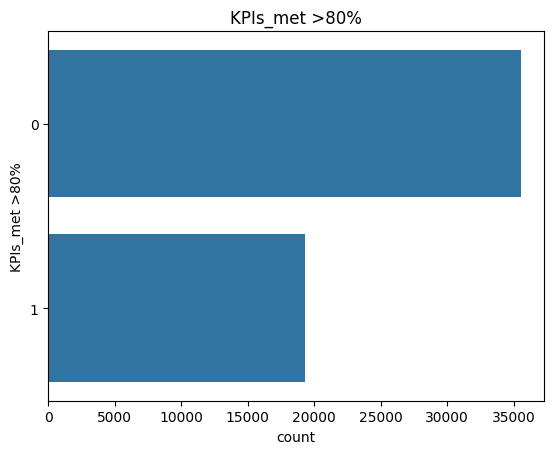

awards_won? 2


awards_won?
0    53538
1     1270
Name: count, dtype: int64

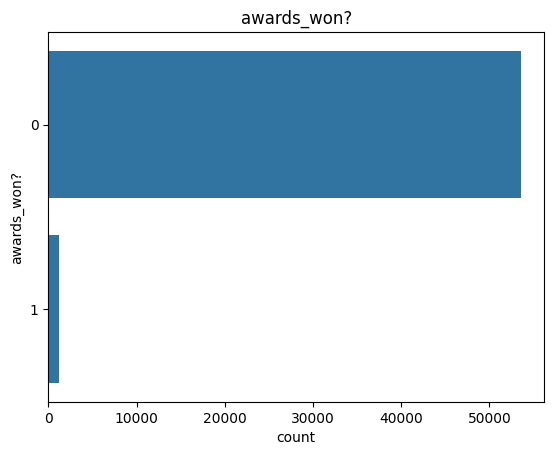

In [14]:
bin_cols = ['KPIs_met >80%','awards_won?']
for b in bin_cols:
    print(b,X[b].nunique())
    display(X[b].value_counts().head(20))
    sns.countplot(y=b,data=X,order=X[b].value_counts().index)
    plt.title(b)
    plt.show()

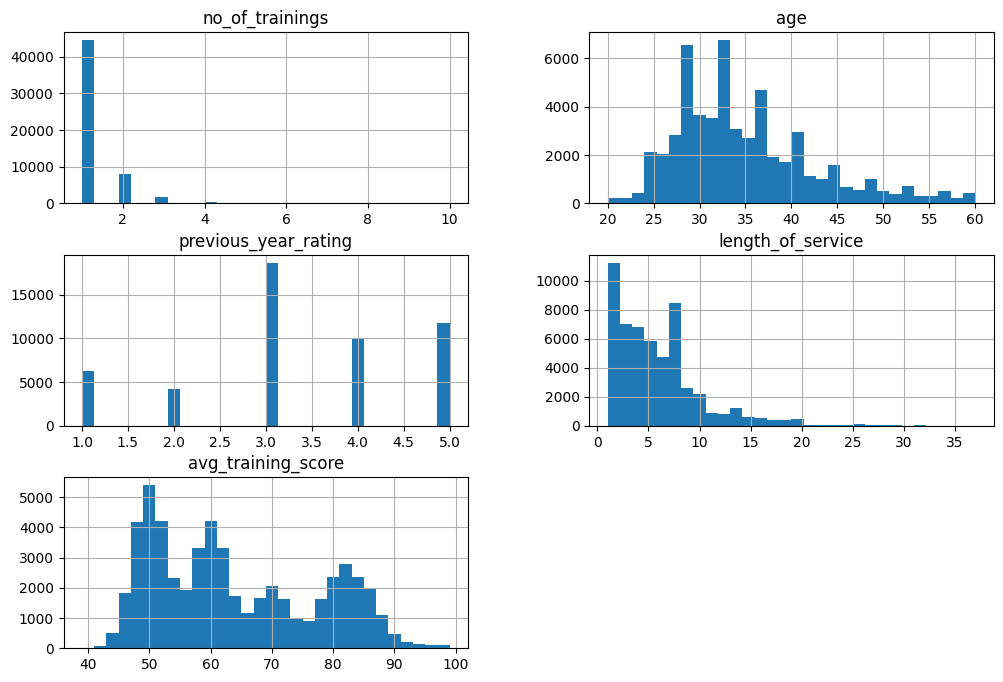

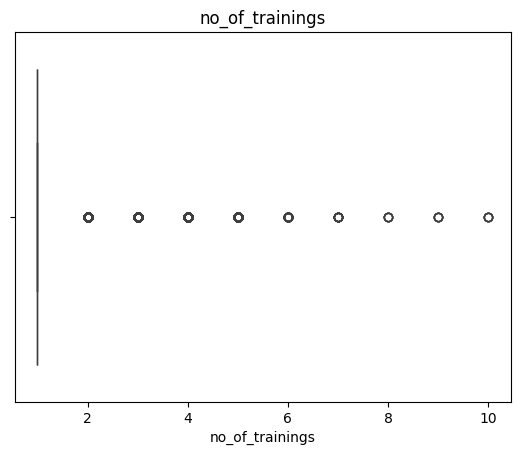

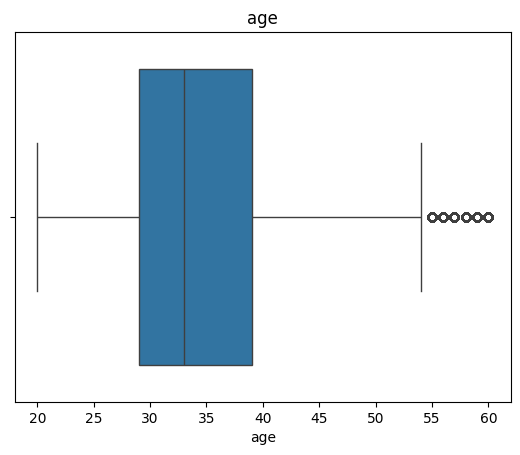

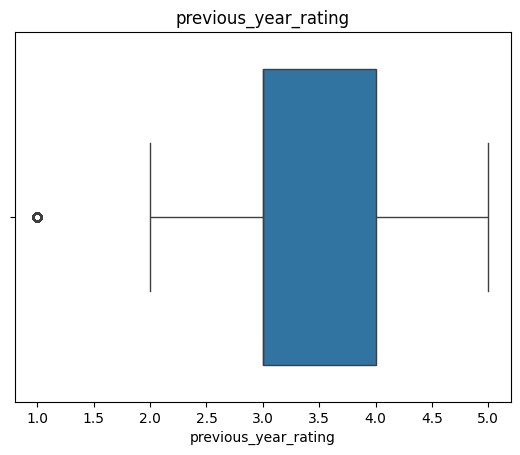

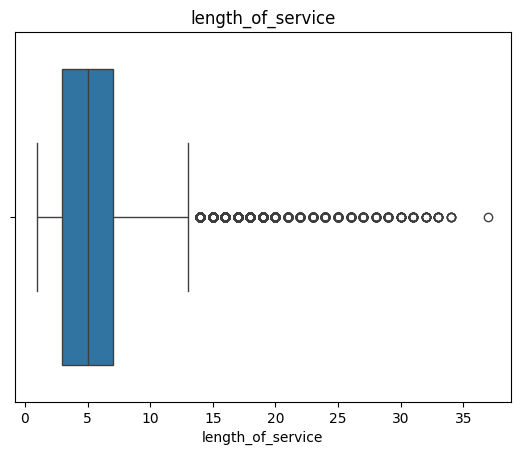

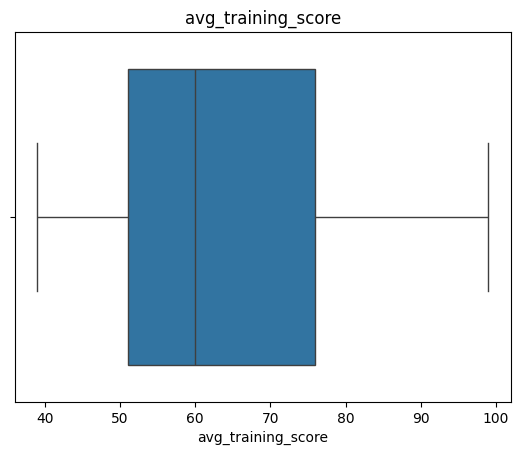

In [15]:
num_cols = ['no_of_trainings','age','previous_year_rating','length_of_service','avg_training_score']
X[num_cols].hist(bins=30,figsize=(12,8))
plt.show()
for n in num_cols:
    sns.boxplot(x=X[n])
    plt.title(n)
    plt.show()

In [16]:
for c in num_cols:
    print(c)
    print(train.groupby(pd.cut(train[c], bins=10))['is_promoted'].mean())


no_of_trainings
no_of_trainings
(0.991, 1.9]    0.088107
(1.9, 2.8]      0.075748
(2.8, 3.7]      0.068694
(3.7, 4.6]      0.055556
(4.6, 5.5]      0.023438
(5.5, 6.4]      0.045455
(6.4, 7.3]      0.000000
(7.3, 8.2]      0.000000
(8.2, 9.1]      0.000000
(9.1, 10.0]     0.000000
Name: is_promoted, dtype: float64
age
age
(19.96, 24.0]    0.076385
(24.0, 28.0]     0.085824
(28.0, 32.0]     0.086646
(32.0, 36.0]     0.095188
(36.0, 40.0]     0.088101
(40.0, 44.0]     0.079963
(44.0, 48.0]     0.063011
(48.0, 52.0]     0.074031
(52.0, 56.0]     0.062348
(56.0, 60.0]     0.059293
Name: is_promoted, dtype: float64
previous_year_rating
previous_year_rating
(0.996, 1.4]    0.014141
(1.4, 1.8]           NaN
(1.8, 2.2]      0.042840
(2.2, 2.6]           NaN
(2.6, 3.0]      0.072779
(3.0, 3.4]           NaN
(3.4, 3.8]           NaN
(3.8, 4.2]      0.079376
(4.2, 4.6]           NaN
(4.6, 5.0]      0.163615
Name: is_promoted, dtype: float64
length_of_service
length_of_service
(0.964, 4.6]    0.08

C:\Users\HP\AppData\Local\Temp\ipykernel_24756\4183226846.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby(pd.cut(train[c], bins=10))['is_promoted'].mean())


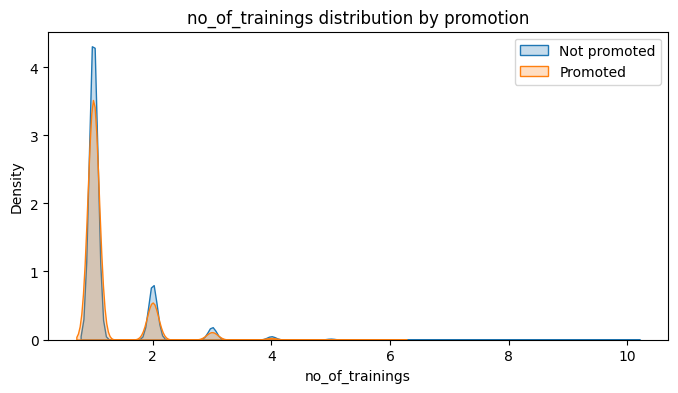

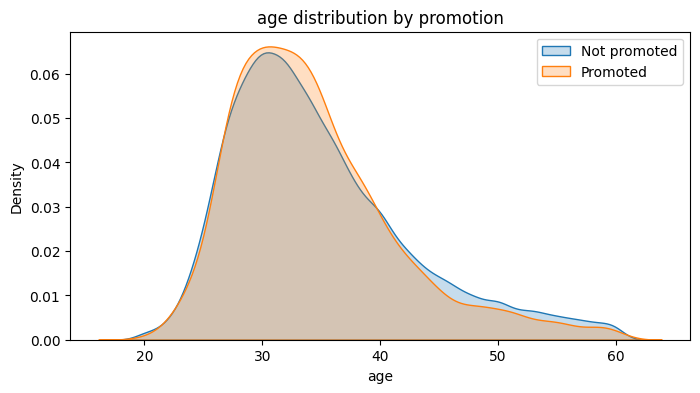

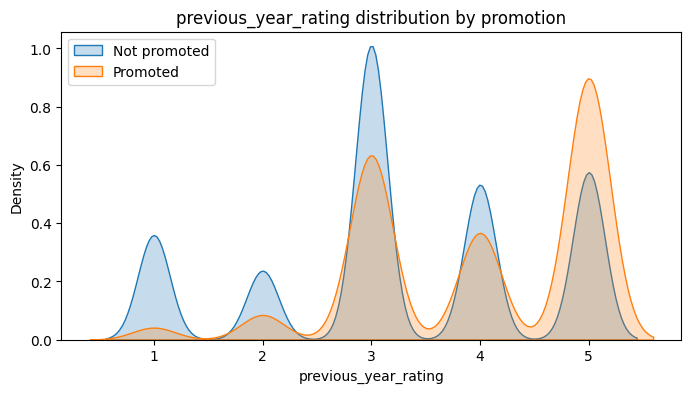

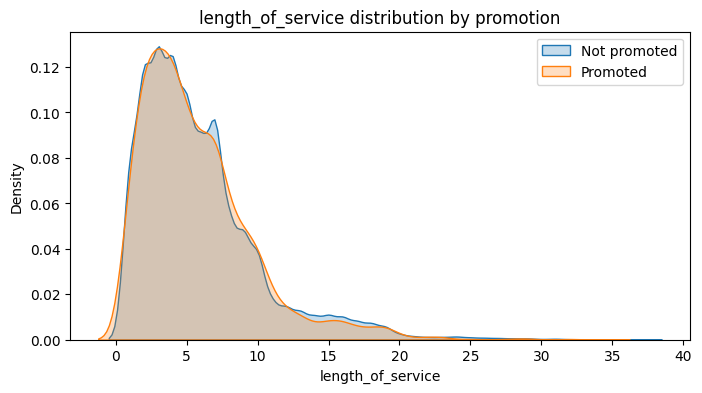

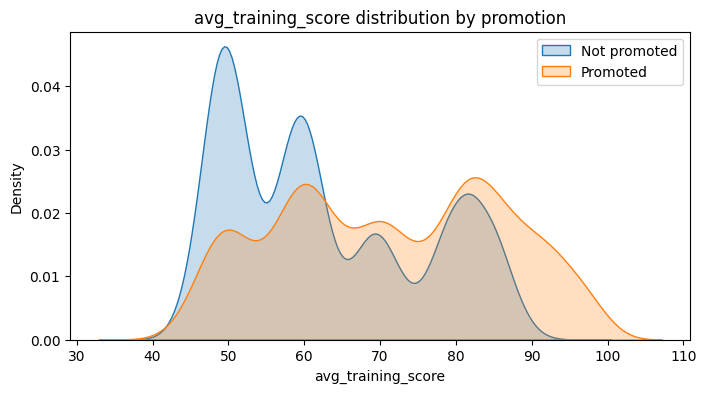

In [17]:
for c in num_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(train.loc[train['is_promoted']==0, c], label='Not promoted', fill=True)
    sns.kdeplot(train.loc[train['is_promoted']==1, c], label='Promoted', fill=True)
    plt.title(f'{c} distribution by promotion')
    plt.legend()
    plt.show()


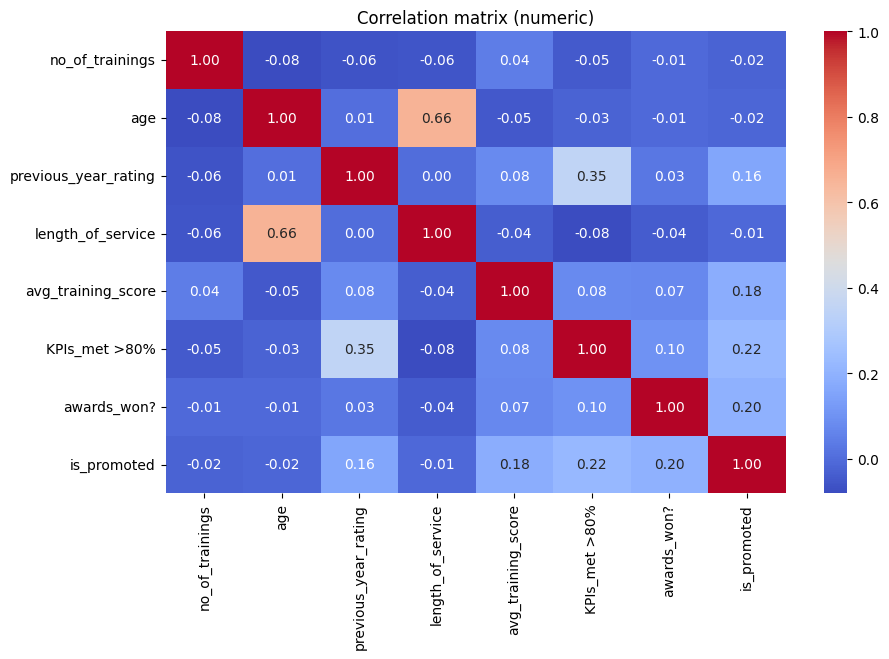

In [18]:
corr = train[num_cols + bin_cols + ['is_promoted']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix (numeric)')
plt.show()

Missing Values

In [19]:
train.isnull().sum()[train.isnull().sum()>0]

education               2409
previous_year_rating    4124
dtype: int64

In [21]:
X['previous_year_rating'].value_counts(dropna=False)



previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
NaN     4124
Name: count, dtype: int64

In [22]:
X['education'].value_counts(dropna=False)

education
Bachelor's          36669
Master's & above    14925
NaN                  2409
Below Secondary       805
Name: count, dtype: int64

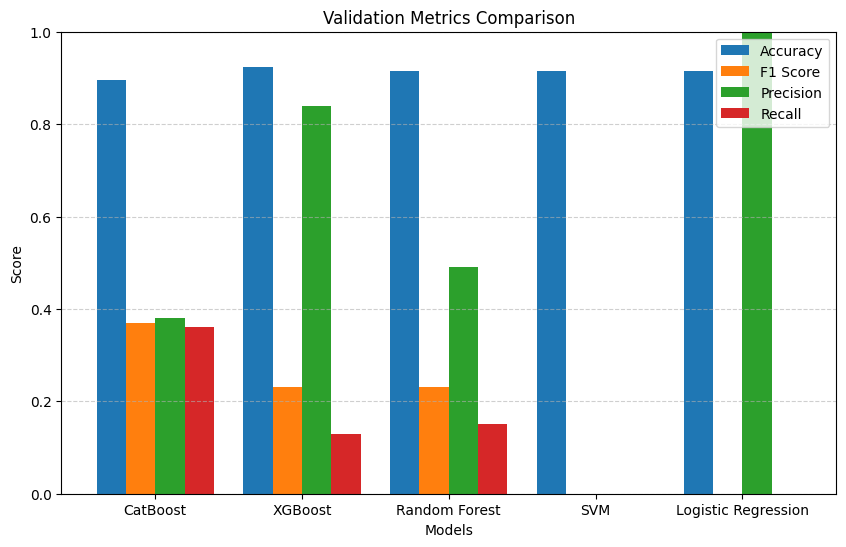

In [4]:
import matplotlib.pyplot as plt
import numpy as np


models = ['CatBoost','XGBoost','Random Forest', 'SVM', 'Logistic Regression']


accuracy = [0.8952,0.9239,0.9142,0.9147,0.9149]
f1_score = [0.3700,0.2300,0.2300,0.0000,0.0000]
precision = [0.3800, 0.8400, 0.4900,0.0000, 1.0000]
recall = [0.3600, 0.1300,0.1500,0.0000,0.0000]

# Create bar positions
x = np.arange(len(models))
width = 0.2

# Plot
plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, f1_score, width, label='F1 Score')
plt.bar(x + 0.5*width, precision, width, label='Precision')
plt.bar(x + 1.5*width, recall, width, label='Recall')

# Style
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Validation Metrics Comparison')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
